In [1]:
import pandas as pd
from scipy.stats import zscore
import seaborn as sns
from scipy.cluster.hierarchy import fcluster
import numpy as np
import matplotlib.pyplot as plt

/ihome/djishnu/alo90/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/ihome/djishnu/alo90/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
header = ['Naive 1', 'Naive 2', 'Naive 3', 'Naive 4', 'Early Pre-TFH 1', 'Early Pre-TFH 2', 'Early Pre-TFH 3', 'Early Pre-TFH 4', 'Late Pre-TFH 1', 'Late Pre-TFH 2', 'Late Pre-TFH 3', 'Late Pre-TFH 4', 'GC 1', 'GC 2', 'GC 3', 'GC 4']

rna_seq = pd.read_csv('/ix/djishnu/Alisa/Tfh/Run_313.atac-seq-correl.rsem.pe.hg38.ensembl.counts.matrix.results.normalized_data_matrix', skiprows = [0], names=header, sep ='\t')
rna_seq = rna_seq.reset_index()

rna_seq = rna_seq.rename(columns={'index': "Gene"})
rna_seq[['Gene_ID', 'Genes']] = rna_seq.Gene.str.split("_",n=1, expand=True)

In [3]:
rna_seq['ATAC_Naive'] = rna_seq[['Naive 1', 'Naive 2', 'Naive 3', 'Naive 4']].mean(axis=1) + 0.000001
rna_seq['ATAC_Early_Pre-TFH'] = rna_seq[['Early Pre-TFH 1', 'Early Pre-TFH 2', 'Early Pre-TFH 3', 'Early Pre-TFH 4']].mean(axis=1) + 0.000001
rna_seq['ATAC_Late_Pre-TFH'] = rna_seq[['Late Pre-TFH 1', 'Late Pre-TFH 2', 'Late Pre-TFH 3', 'Late Pre-TFH 4']].mean(axis=1) + 0.000001
rna_seq['ATAC_GC'] = rna_seq[['GC 1', 'GC 2', 'GC 3', 'GC 4']].mean(axis=1) + 0.000001
rna_seq_mean = rna_seq[['Genes', 'ATAC_Naive','ATAC_Early_Pre-TFH', 'ATAC_Late_Pre-TFH', 'ATAC_GC']]

In [4]:
rna_seq['ATAC_Naive_sd']   = rna_seq[['Naive 1', 'Naive 2', 'Naive 3', 'Naive 4']].std(axis=1)
rna_seq['ATAC_Early_Pre-TFH_sd']   = rna_seq[['Early Pre-TFH 1', 'Early Pre-TFH 2',
                                              'Early Pre-TFH 3', 'Early Pre-TFH 4']].std(axis=1)
rna_seq['ATAC_Late_Pre-TFH_sd']   = rna_seq[['Late Pre-TFH 1', 'Late Pre-TFH 2',
                                             'Late Pre-TFH 3', 'Late Pre-TFH 4']].std(axis=1)
rna_seq['ATAC_GC_sd']   = rna_seq[['GC 1', 'GC 2', 'GC 3', 'GC 4']].std(axis=1)

In [5]:
rna_seq_mean = rna_seq[['Genes', 'ATAC_Naive','ATAC_Early_Pre-TFH', 'ATAC_Late_Pre-TFH', 'ATAC_GC']].rename(columns={
    'ATAC_Naive': 'Naive',
    'ATAC_Early_Pre-TFH': 'Early_Extra_GC_Tfh',
    'ATAC_Late_Pre-TFH': 'Late_Extra_GC_Tfh',
    'ATAC_GC': 'GC Tfh'
})

In [6]:
gene = 'IL12RB2'

means = rna_seq.loc[rna_seq['Genes'] == gene,
    ['ATAC_Naive',
     'ATAC_Early_Pre-TFH',
     'ATAC_Late_Pre-TFH',
     'ATAC_GC']
].values.flatten()


sds = rna_seq.loc[rna_seq['Genes'] == gene,
    ['ATAC_Naive_sd',
     'ATAC_Early_Pre-TFH_sd',
     'ATAC_Late_Pre-TFH_sd',
     'ATAC_GC_sd']
].values.flatten()

labels = ['Naive', 'Early Pre-Tfh', 'Late Pre-Tfh', 'GC Tfh']

replicate_cols = [
    ['Naive 1', 'Naive 2', 'Naive 3', 'Naive 4'],
    ['Early Pre-TFH 1', 'Early Pre-TFH 2', 'Early Pre-TFH 3', 'Early Pre-TFH 4'],
    ['Late Pre-TFH 1', 'Late Pre-TFH 2', 'Late Pre-TFH 3', 'Late Pre-TFH 4'],
    ['GC 1', 'GC 2', 'GC 3', 'GC 4'],
]
replicate_values = [
    rna_seq.loc[rna_seq['Genes'] == gene, cols].values.flatten()
    for cols in replicate_cols
]

In [7]:
upper_err = sds
lower_err = np.zeros_like(sds)
yerr = np.vstack([lower_err, upper_err])

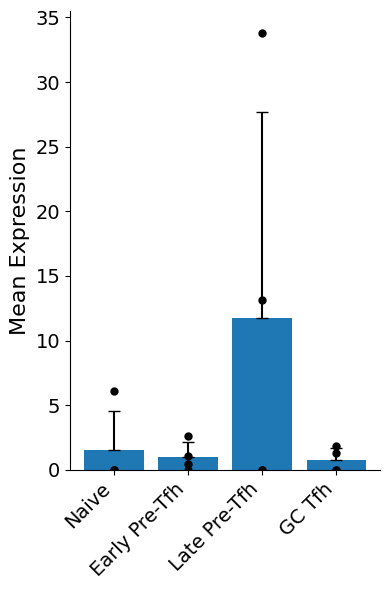

In [8]:
fig, ax = plt.subplots(figsize=(4, 6))  # narrower width, taller height

ax.bar(
    labels,
    means,
    yerr=yerr,
    capsize=4,
    linewidth=0
)

# Overlay individual replicate dots
for i, vals in enumerate(replicate_values):
    ax.scatter(
        np.full_like(vals, i, dtype=float),
        vals,
        color='black',
        s=25,
        zorder=3,
    )
# Axis labels and fonts
ax.set_ylabel('Mean Expression', fontsize=16)
plt.xticks(labels, fontsize= 16, rotation=45, ha='right')
ax.tick_params(axis='both', labelsize=14)

# Clean spines (only x and y)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    '/ix/djishnu/Alisa/Tfh/testing_for_github/Extended_Figure_9/IL12RB2_expression_mean_sd.png',
    dpi=300,
    bbox_inches='tight'
)
plt.savefig(
    '/ix/djishnu/Alisa/Tfh/testing_for_github/Extended_Figure_9/IL12RB2_expression_mean_sd.pdf',
    dpi=300,
    bbox_inches='tight'
)
